# Data Scrubbing
- Gabriel Marcellino
- 18222115

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

In [2]:
data_hotel = pd.read_csv("../data/processed/hotel_clean.csv")
data_odtw = pd.read_csv("../data/processed/odtw_clean.csv")

---
## 1. Data Exploration
> Eksplorasi dilakukan untuk memahami kondisi data sebelum preprocessing. Setiap temuan di sini menjadi dasar keputusan preprocessing yang dilakukan di Section 2.

### 1.1 Hotel — Missing Value Analysis
**Temuan → H1, H2**

In [3]:
# Overall missing summary
print("=== hotel_clean.csv ===")
print(f"Shape : {data_hotel.shape}")
print()
print(data_hotel.isnull().sum().rename("missing").to_frame().assign(
    pct=lambda d: (d['missing'] / len(data_hotel) * 100).round(1)
))

=== hotel_clean.csv ===
Shape : (1008, 4)

             missing   pct
tahun              0   0.0
bulan              0   0.0
jenis_hotel        0   0.0
tpk              576  57.1


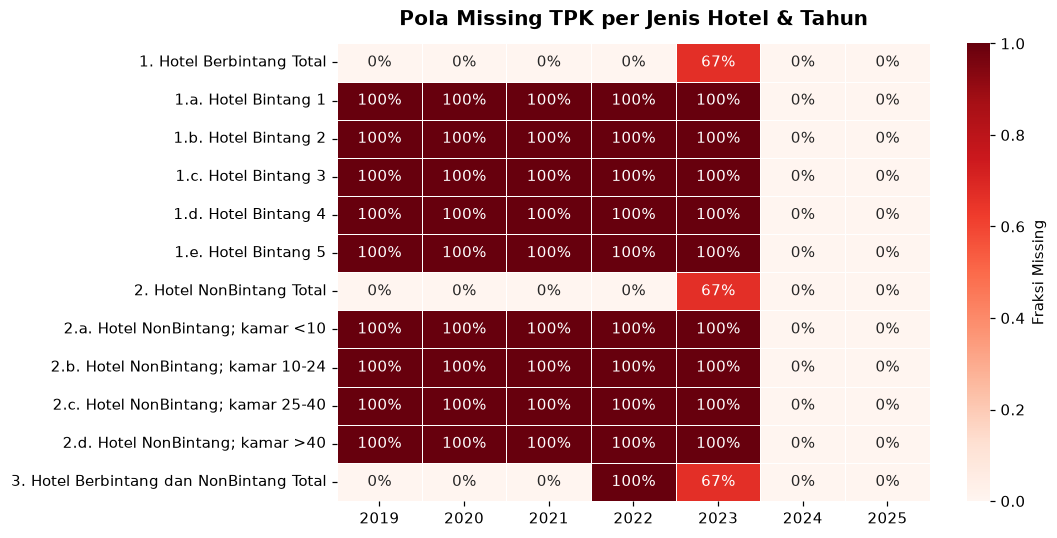


Insight:
- Kategori sub-bintang (Bintang 1–5) dan NonBintang per ukuran missing 71–100% di 2019–2023.
- Kategori agregat (Berbintang Total, NonBintang Total, Total) jauh lebih lengkap.
- → H1: Filter ke kategori agregat saja untuk analisis tren.
- → H2: Interpolasi linear untuk sisa missing pada kategori agregat.



In [4]:
# Missing pattern: per jenis_hotel x tahun (heatmap)
missing_pivot = (
    data_hotel
    .assign(missing=data_hotel['tpk'].isnull().astype(int))
    .groupby(['jenis_hotel', 'tahun'])['missing']
    .mean()
    .unstack('tahun')
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    missing_pivot, annot=True, fmt='.0%', cmap='Reds',
    linewidths=0.4, cbar_kws={'label': 'Fraksi Missing'},
    ax=ax
)
ax.set_title('Pola Missing TPK per Jenis Hotel & Tahun', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

print("""
Insight:
- Kategori sub-bintang (Bintang 1–5) dan NonBintang per ukuran missing 71–100% di 2019–2023.
- Kategori agregat (Berbintang Total, NonBintang Total, Total) jauh lebih lengkap.
- → H1: Filter ke kategori agregat saja untuk analisis tren.
- → H2: Interpolasi linear untuk sisa missing pada kategori agregat.
""")

### 1.2 Hotel — Format Kolom & Urutan Kronologis
**Temuan → H3, H4**

In [5]:
print("Tipe data kolom hotel:")
print(data_hotel.dtypes)
print()

# Demo masalah sorting string bulan
bulan_str_order = data_hotel['bulan'].unique().tolist()
print("Urutan bulan saat ini (string, bukan kronologis):")
print(bulan_str_order)

print("""
Insight:
- Kolom 'tahun' bertipe object (string), 'tpk' float — tahun perlu dikonversi ke int.
- Kolom 'bulan' berisi nama Indonesia; tanpa konversi numerik, sorting akan alfabetikal
  (April, Agustus, ... bukan Januari, Februari, ...).
- → H3: Tambah kolom 'bulan_num' (int 1–12).
- → H4: Tambah kolom 'periode' (datetime YYYY-MM) untuk time series plotting.
""")

Tipe data kolom hotel:
tahun            int64
bulan              str
jenis_hotel        str
tpk            float64
dtype: object

Urutan bulan saat ini (string, bukan kronologis):
['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember']

Insight:
- Kolom 'tahun' bertipe object (string), 'tpk' float — tahun perlu dikonversi ke int.
- Kolom 'bulan' berisi nama Indonesia; tanpa konversi numerik, sorting akan alfabetikal
  (April, Agustus, ... bukan Januari, Februari, ...).
- → H3: Tambah kolom 'bulan_num' (int 1–12).
- → H4: Tambah kolom 'periode' (datetime YYYY-MM) untuk time series plotting.



### 1.3 Hotel — Dampak COVID pada TPK
**Temuan → H5**

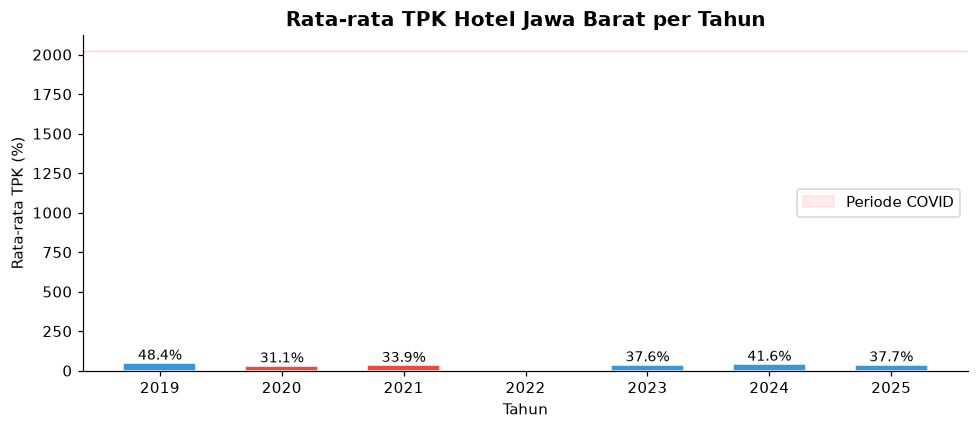


Insight:
- Penurunan tajam TPK terjadi di 2020–2021 akibat pandemi COVID-19.
- Tahun 2022 bahkan lebih rendah dari 2021 (mungkin data parsial).
- Periode COVID merupakan outlier struktural, bukan noise acak — perlu ditandai
  agar model tidak salah menginterpretasi penurunan ini sebagai tren normal.
- → H5: Tambah kolom boolean 'is_covid' (True untuk 2020–2021).



In [6]:
bulan_map = {
    'Januari':1,'Februari':2,'Maret':3,'April':4,'Mei':5,'Juni':6,
    'Juli':7,'Agustus':8,'September':9,'Oktober':10,'November':11,'Desember':12
}

# Preview tren Total menggunakan data yang tersedia
total_df = data_hotel[data_hotel['jenis_hotel'] == '3. Hotel Berbintang dan NonBintang Total'].copy()
total_df['bulan_num'] = total_df['bulan'].map(bulan_map)
total_df['tahun'] = total_df['tahun'].astype(int)
total_df = total_df.sort_values(['tahun', 'bulan_num'])

avg_tpk = total_df.groupby('tahun')['tpk'].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(avg_tpk['tahun'], avg_tpk['tpk'],
       color=['#e74c3c' if y in [2020, 2021] else '#3498db' for y in avg_tpk['tahun']],
       edgecolor='white', width=0.6)
ax.axhspan(2019.5, 2021.5, alpha=0.08, color='red', label='Periode COVID')
ax.set_xlabel('Tahun')
ax.set_ylabel('Rata-rata TPK (%)')
ax.set_title('Rata-rata TPK Hotel Jawa Barat per Tahun', fontsize=13, fontweight='bold')
ax.set_xticks(avg_tpk['tahun'])
ax.legend()
for bar, val in zip(ax.patches, avg_tpk['tpk']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print("""
Insight:
- Penurunan tajam TPK terjadi di 2020–2021 akibat pandemi COVID-19.
- Tahun 2022 bahkan lebih rendah dari 2021 (mungkin data parsial).
- Periode COVID merupakan outlier struktural, bukan noise acak — perlu ditandai
  agar model tidak salah menginterpretasi penurunan ini sebagai tren normal.
- → H5: Tambah kolom boolean 'is_covid' (True untuk 2020–2021).
""")

### 1.4 ODTW — Distribusi Zeros & Kategori
**Temuan → O1, O2, O3**

In [7]:
print("=== odtw_clean.csv ===")
print(f"Shape  : {data_odtw.shape}")
print(f"Dtypes :\n{data_odtw.dtypes}")
print(f"\nMissing:\n{data_odtw.isnull().sum()}")

zeros = data_odtw[data_odtw['jumlah_objek_wisata'] == 0]
print(f"\nBaris dengan nilai 0 : {len(zeros)} ({len(zeros)/len(data_odtw)*100:.1f}%)")
print("\nDistribusi zeros per kategori:")
print(zeros.groupby('kategori_wisata').size().sort_values(ascending=False))

=== odtw_clean.csv ===
Shape  : (888, 5)
Dtypes :
tahun                  int64
kode_wilayah           int64
kabupaten_kota           str
kategori_wisata          str
jumlah_objek_wisata    int64
dtype: object

Missing:
tahun                  0
kode_wilayah           0
kabupaten_kota         0
kategori_wisata        0
jumlah_objek_wisata    0
dtype: int64

Baris dengan nilai 0 : 92 (10.4%)

Distribusi zeros per kategori:
kategori_wisata
BUDAYA          33
MINAT KHUSUS    32
ALAM            18
BUATAN           9
dtype: int64


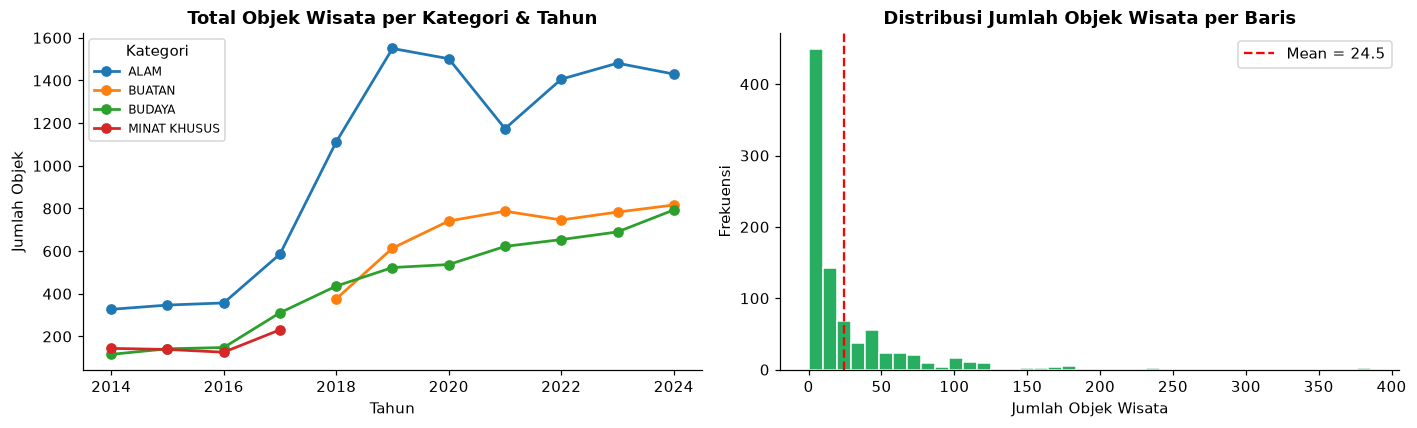


Insight:
- Nilai 0 (10.4%) terkonsentrasi di kategori MINAT KHUSUS & BUDAYA di kabupaten kecil
  dan tahun awal (2014–2016) — kemungkinan 'belum ada' bukan 'tidak dilaporkan'.
  → O1: Flag zeros dengan kolom 'is_zero_record'; tidak dihapus agar tren terlihat.
- Format saat ini long (satu baris per kabupaten × kategori × tahun) — untuk
  analisis korelasi antar kategori atau clustering kabupaten perlu bentuk wide.
  → O2: Pivot wide dengan kolom per kategori wisata.
- Belum ada kolom agregat total objek per kabupaten per tahun.
  → O3: Tambah kolom 'total_objek_wisata'.



In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Kiri: total objek per kategori per tahun
pivot_kat = data_odtw.groupby(['tahun', 'kategori_wisata'])['jumlah_objek_wisata'].sum().unstack()
pivot_kat.plot(ax=axes[0], marker='o', linewidth=1.8)
axes[0].set_title('Total Objek Wisata per Kategori & Tahun', fontweight='bold')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Jumlah Objek')
axes[0].legend(title='Kategori', fontsize=8)

# Kanan: distribusi jumlah_objek_wisata (histogram)
axes[1].hist(data_odtw['jumlah_objek_wisata'], bins=40, color='#27ae60', edgecolor='white')
axes[1].axvline(data_odtw['jumlah_objek_wisata'].mean(), color='red', linestyle='--', label=f"Mean = {data_odtw['jumlah_objek_wisata'].mean():.1f}")
axes[1].set_title('Distribusi Jumlah Objek Wisata per Baris', fontweight='bold')
axes[1].set_xlabel('Jumlah Objek Wisata')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout()
plt.show()

print("""
Insight:
- Nilai 0 (10.4%) terkonsentrasi di kategori MINAT KHUSUS & BUDAYA di kabupaten kecil
  dan tahun awal (2014–2016) — kemungkinan 'belum ada' bukan 'tidak dilaporkan'.
  → O1: Flag zeros dengan kolom 'is_zero_record'; tidak dihapus agar tren terlihat.
- Format saat ini long (satu baris per kabupaten × kategori × tahun) — untuk
  analisis korelasi antar kategori atau clustering kabupaten perlu bentuk wide.
  → O2: Pivot wide dengan kolom per kategori wisata.
- Belum ada kolom agregat total objek per kabupaten per tahun.
  → O3: Tambah kolom 'total_objek_wisata'.
""")

### 1.5 ODTW — Variasi Antar Kabupaten & Kebutuhan Normalisasi
**Temuan → O4, O5**

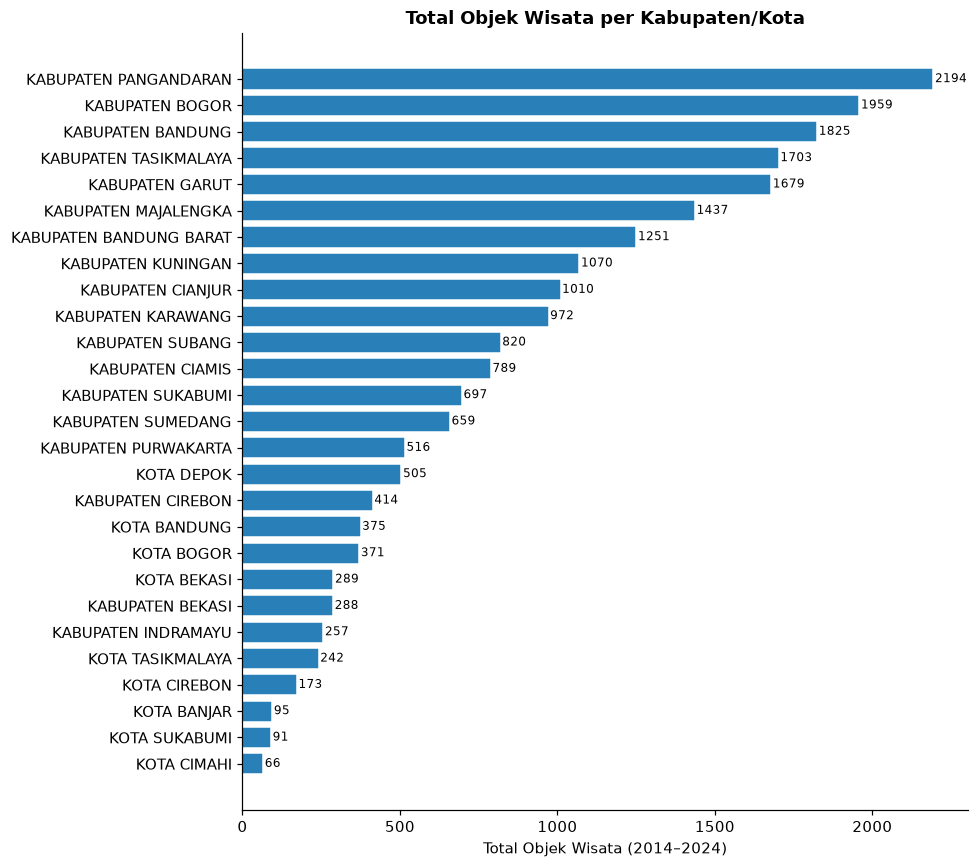

Ratio max/min (non-zero): 33.2x
Max: KABUPATEN PANGANDARAN = 2194
Min (non-zero): KOTA CIMAHI = 66

Insight:
- Rentang total objek sangat lebar antar kabupaten — rasio max/min bisa >40x.
  Tanpa normalisasi, clustering akan didominasi kabupaten besar (Bogor, Bandung).
  → O4: Normalisasi min-max per tahun sebelum clustering.
- kode_wilayah memiliki pola geografis (320x): belum ada label wilayah eksplisit.
  → O5: Tambah kolom 'wilayah' berdasarkan pengelompokan kode & nama kabupaten.



In [9]:
total_per_kab = (
    data_odtw.groupby('kabupaten_kota')['jumlah_objek_wisata']
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(total_per_kab.index, total_per_kab.values, color='#2980b9', edgecolor='white')
ax.set_xlabel('Total Objek Wisata (2014–2024)')
ax.set_title('Total Objek Wisata per Kabupaten/Kota', fontweight='bold')
for bar, val in zip(bars, total_per_kab.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=8)
plt.tight_layout()
plt.show()

ratio = total_per_kab.max() / total_per_kab[total_per_kab > 0].min()
print(f"Ratio max/min (non-zero): {ratio:.1f}x")
print(f"Max: {total_per_kab.idxmax()} = {total_per_kab.max()}")
print(f"Min (non-zero): {total_per_kab[total_per_kab>0].idxmin()} = {total_per_kab[total_per_kab>0].min()}")

print("""
Insight:
- Rentang total objek sangat lebar antar kabupaten — rasio max/min bisa >40x.
  Tanpa normalisasi, clustering akan didominasi kabupaten besar (Bogor, Bandung).
  → O4: Normalisasi min-max per tahun sebelum clustering.
- kode_wilayah memiliki pola geografis (320x): belum ada label wilayah eksplisit.
  → O5: Tambah kolom 'wilayah' berdasarkan pengelompokan kode & nama kabupaten.
""")

### 1.6 Lintas Dataset — Overlap Rentang Tahun
**Temuan → L1, L2**

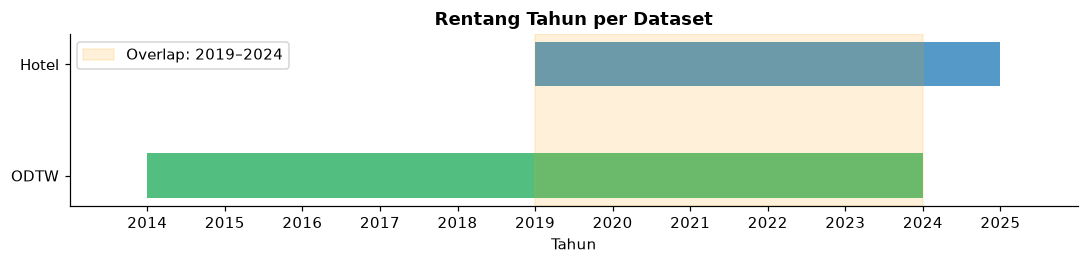

Hotel years  : [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
ODTW years   : [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Overlap      : [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Insight:
- Hotel mencakup 2019–2025, ODTW mencakup 2014–2024.
- Overlap hanya 2019–2024 (6 tahun) — analisis gabungan harus dibatasi ke rentang ini.
  → L1: Saat merge, filter ke tahun 2019–2024.
- Kedua dataset belum pernah digabungkan; analisis korelasi TPK vs jumlah objek wisata
  per tahun belum dilakukan.
  → L2: Buat df_merged untuk analisis lanjutan.



In [10]:
hotel_years = sorted(data_hotel['tahun'].astype(int).unique())
odtw_years  = sorted(data_odtw['tahun'].astype(int).unique())
overlap     = sorted(set(hotel_years) & set(odtw_years))

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.barh(['ODTW', 'Hotel'], 
        [odtw_years[-1] - odtw_years[0], hotel_years[-1] - hotel_years[0]],
        left=[odtw_years[0], hotel_years[0]],
        color=['#27ae60', '#2980b9'], height=0.4, alpha=0.8)
ax.axvspan(overlap[0], overlap[-1], alpha=0.15, color='orange', label=f'Overlap: {overlap[0]}–{overlap[-1]}')
ax.set_xlabel('Tahun')
ax.set_title('Rentang Tahun per Dataset', fontweight='bold')
ax.set_xlim(2013, 2026)
ax.set_xticks(range(2014, 2026))
ax.legend()
plt.tight_layout()
plt.show()

print(f"Hotel years  : {hotel_years}")
print(f"ODTW years   : {odtw_years}")
print(f"Overlap      : {overlap}")

print("""
Insight:
- Hotel mencakup 2019–2025, ODTW mencakup 2014–2024.
- Overlap hanya 2019–2024 (6 tahun) — analisis gabungan harus dibatasi ke rentang ini.
  → L1: Saat merge, filter ke tahun 2019–2024.
- Kedua dataset belum pernah digabungkan; analisis korelasi TPK vs jumlah objek wisata
  per tahun belum dilakukan.
  → L2: Buat df_merged untuk analisis lanjutan.
""")

---
## 2. Preprocessing

### 2.1 Hotel — H1: Filter Kategori Agregat

In [11]:
AGREGAT_COLS = [
    '1. Hotel Berbintang Total',
    '2. Hotel NonBintang Total',
    '3. Hotel Berbintang dan NonBintang Total',
]

hotel = data_hotel[data_hotel['jenis_hotel'].isin(AGREGAT_COLS)].copy()
print(f"Sebelum filter: {len(data_hotel)} baris")
print(f"Setelah filter (kategori agregat): {len(hotel)} baris")
print(f"\nMissing tpk setelah filter: {hotel['tpk'].isnull().sum()} ({hotel['tpk'].isnull().mean()*100:.1f}%)")

Sebelum filter: 1008 baris
Setelah filter (kategori agregat): 252 baris

Missing tpk setelah filter: 36 (14.3%)


### 2.2 Hotel — H3 & H4: Konversi Tipe + Kolom bulan_num & periode

In [12]:
BULAN_MAP = {
    'Januari':1, 'Februari':2, 'Maret':3, 'April':4,
    'Mei':5, 'Juni':6, 'Juli':7, 'Agustus':8,
    'September':9, 'Oktober':10, 'November':11, 'Desember':12
}

hotel['tahun']     = hotel['tahun'].astype(int)
hotel['bulan_num'] = hotel['bulan'].map(BULAN_MAP)
hotel['periode']   = pd.to_datetime(
    hotel['tahun'].astype(str) + '-' + hotel['bulan_num'].astype(str).str.zfill(2)
)

hotel = hotel.sort_values(['jenis_hotel', 'periode']).reset_index(drop=True)
print(hotel[['tahun', 'bulan', 'bulan_num', 'periode', 'jenis_hotel', 'tpk']].head(10))

   tahun      bulan  bulan_num    periode                jenis_hotel    tpk
0   2019    Januari          1 2019-01-01  1. Hotel Berbintang Total  54.33
1   2019   Februari          2 2019-02-01  1. Hotel Berbintang Total  51.57
2   2019      Maret          3 2019-03-01  1. Hotel Berbintang Total  52.69
3   2019      April          4 2019-04-01  1. Hotel Berbintang Total  53.17
4   2019        Mei          5 2019-05-01  1. Hotel Berbintang Total  38.79
5   2019       Juni          6 2019-06-01  1. Hotel Berbintang Total  53.13
6   2019       Juli          7 2019-07-01  1. Hotel Berbintang Total  54.69
7   2019    Agustus          8 2019-08-01  1. Hotel Berbintang Total  49.58
8   2019  September          9 2019-09-01  1. Hotel Berbintang Total  50.60
9   2019    Oktober         10 2019-10-01  1. Hotel Berbintang Total  56.07


### 2.3 Hotel — H2: Interpolasi Linear Missing TPK

In [13]:
before_missing = hotel['tpk'].isnull().sum()

hotel['tpk'] = (
    hotel
    .groupby('jenis_hotel')['tpk']
    .transform(lambda s: s.interpolate(method='linear', limit_direction='both'))
)

after_missing = hotel['tpk'].isnull().sum()
print(f"Missing sebelum interpolasi : {before_missing}")
print(f"Missing setelah interpolasi : {after_missing}")
print(f"\nSample hasil interpolasi:")
print(hotel[hotel['jenis_hotel'] == '3. Hotel Berbintang dan NonBintang Total'][['periode','tpk']].head(15))

Missing sebelum interpolasi : 36
Missing setelah interpolasi : 0

Sample hasil interpolasi:
       periode    tpk
168 2019-01-01  51.45
169 2019-02-01  48.08
170 2019-03-01  48.81
171 2019-04-01  49.19
172 2019-05-01  36.47
173 2019-06-01  47.57
174 2019-07-01  49.03
175 2019-08-01  46.26
176 2019-09-01  47.57
177 2019-10-01  50.36
178 2019-11-01  51.59
179 2019-12-01  54.82
180 2020-01-01  45.96
181 2020-02-01  46.47
182 2020-03-01  28.73


### 2.4 Hotel — H5: Flag Periode COVID

In [14]:
hotel['is_covid'] = hotel['tahun'].isin([2020, 2021])

print(hotel.groupby(['tahun', 'is_covid']).size().reset_index(name='baris'))
print(f"\nTotal baris COVID : {hotel['is_covid'].sum()}")
print(f"Total baris normal: {(~hotel['is_covid']).sum()}")

   tahun  is_covid  baris
0   2019     False     36
1   2020      True     36
2   2021      True     36
3   2022     False     36
4   2023     False     36
5   2024     False     36
6   2025     False     36

Total baris COVID : 72
Total baris normal: 180


### 2.5 Hotel — Ringkasan Akhir

In [15]:
print("=== hotel (processed) ===")
print(hotel.dtypes)
print()
print(hotel.head())
print(f"\nShape: {hotel.shape}")
print(f"Missing tpk: {hotel['tpk'].isnull().sum()}")

=== hotel (processed) ===
tahun                   int64
bulan                     str
jenis_hotel               str
tpk                   float64
bulan_num               int64
periode        datetime64[us]
is_covid                 bool
dtype: object

   tahun     bulan                jenis_hotel    tpk  bulan_num    periode  \
0   2019   Januari  1. Hotel Berbintang Total  54.33          1 2019-01-01   
1   2019  Februari  1. Hotel Berbintang Total  51.57          2 2019-02-01   
2   2019     Maret  1. Hotel Berbintang Total  52.69          3 2019-03-01   
3   2019     April  1. Hotel Berbintang Total  53.17          4 2019-04-01   
4   2019       Mei  1. Hotel Berbintang Total  38.79          5 2019-05-01   

   is_covid  
0     False  
1     False  
2     False  
3     False  
4     False  

Shape: (252, 7)
Missing tpk: 0


---
### 2.6 ODTW — O1: Flag Zeros

In [16]:
odtw = data_odtw.copy()
odtw['tahun'] = odtw['tahun'].astype(int)

odtw['is_zero_record'] = odtw['jumlah_objek_wisata'] == 0

print(f"Zero records : {odtw['is_zero_record'].sum()} ({odtw['is_zero_record'].mean()*100:.1f}%)")
print(f"Non-zero     : {(~odtw['is_zero_record']).sum()}")
print()
print("Zeros per kategori:")
print(odtw[odtw['is_zero_record']].groupby('kategori_wisata').size())

Zero records : 92 (10.4%)
Non-zero     : 796

Zeros per kategori:
kategori_wisata
ALAM            18
BUATAN           9
BUDAYA          33
MINAT KHUSUS    32
dtype: int64


### 2.7 ODTW — O5: Tambah Kolom Wilayah

In [17]:
WILAYAH_MAP = {
    # Priangan Timur
    'KABUPATEN GARUT'         : 'Priangan Timur',
    'KABUPATEN TASIKMALAYA'   : 'Priangan Timur',
    'KOTA TASIKMALAYA'        : 'Priangan Timur',
    'KABUPATEN CIAMIS'        : 'Priangan Timur',
    'KOTA BANJAR'             : 'Priangan Timur',
    'KABUPATEN PANGANDARAN'   : 'Priangan Timur',
    # Priangan Barat
    'KABUPATEN BANDUNG'       : 'Priangan Barat',
    'KABUPATEN BANDUNG BARAT' : 'Priangan Barat',
    'KOTA BANDUNG'            : 'Priangan Barat',
    'KOTA CIMAHI'             : 'Priangan Barat',
    'KABUPATEN SUMEDANG'      : 'Priangan Barat',
    'KABUPATEN CIANJUR'       : 'Priangan Barat',
    # Bogor-Sukabumi
    'KABUPATEN BOGOR'         : 'Bogor-Sukabumi',
    'KOTA BOGOR'              : 'Bogor-Sukabumi',
    'KABUPATEN SUKABUMI'      : 'Bogor-Sukabumi',
    'KOTA SUKABUMI'           : 'Bogor-Sukabumi',
    # Pantura Barat
    'KABUPATEN KARAWANG'      : 'Pantura Barat',
    'KABUPATEN PURWAKARTA'    : 'Pantura Barat',
    'KABUPATEN SUBANG'        : 'Pantura Barat',
    'KABUPATEN BEKASI'        : 'Pantura Barat',
    'KOTA BEKASI'             : 'Pantura Barat',
    'KOTA DEPOK'              : 'Pantura Barat',
    # Pantura Timur
    'KABUPATEN INDRAMAYU'     : 'Pantura Timur',
    'KABUPATEN MAJALENGKA'    : 'Pantura Timur',
    'KABUPATEN CIREBON'       : 'Pantura Timur',
    'KOTA CIREBON'            : 'Pantura Timur',
    'KABUPATEN KUNINGAN'      : 'Pantura Timur',
}

odtw['wilayah'] = odtw['kabupaten_kota'].map(WILAYAH_MAP)

print("Distribusi kabupaten per wilayah:")
print(odtw.drop_duplicates('kabupaten_kota').groupby('wilayah')['kabupaten_kota'].count())
print(f"\nUnmapped: {odtw['wilayah'].isnull().sum()}")

Distribusi kabupaten per wilayah:
wilayah
Bogor-Sukabumi    4
Pantura Barat     6
Pantura Timur     5
Priangan Barat    6
Priangan Timur    6
Name: kabupaten_kota, dtype: int64

Unmapped: 0


### 2.8 ODTW — O3: Tambah Kolom total_objek_wisata

In [18]:
total_per_kab_tahun = (
    odtw.groupby(['tahun', 'kabupaten_kota'])['jumlah_objek_wisata']
    .sum()
    .reset_index(name='total_objek_wisata')
)

odtw = odtw.merge(total_per_kab_tahun, on=['tahun', 'kabupaten_kota'], how='left')

print("Sample kolom baru:")
print(odtw[['tahun','kabupaten_kota','kategori_wisata','jumlah_objek_wisata','total_objek_wisata']].head(8))

Sample kolom baru:
   tahun      kabupaten_kota kategori_wisata  jumlah_objek_wisata  \
0   2014     KABUPATEN BOGOR            ALAM                   38   
1   2014     KABUPATEN BOGOR          BUDAYA                    3   
2   2014     KABUPATEN BOGOR    MINAT KHUSUS                    4   
3   2014  KABUPATEN SUKABUMI            ALAM                   36   
4   2014  KABUPATEN SUKABUMI          BUDAYA                    7   
5   2014  KABUPATEN SUKABUMI    MINAT KHUSUS                    7   
6   2014   KABUPATEN CIANJUR            ALAM                   12   
7   2014   KABUPATEN CIANJUR          BUDAYA                    4   

   total_objek_wisata  
0                  45  
1                  45  
2                  45  
3                  50  
4                  50  
5                  50  
6                  17  
7                  17  


### 2.9 ODTW — O2: Pivot Wide (per Kategori)

In [19]:
odtw_wide = odtw.pivot_table(
    index=['tahun', 'kode_wilayah', 'kabupaten_kota', 'wilayah', 'total_objek_wisata'],
    columns='kategori_wisata',
    values='jumlah_objek_wisata',
    aggfunc='sum'
).reset_index()

# Bersihkan nama kolom
odtw_wide.columns.name = None
odtw_wide.columns = [
    c.lower().replace(' ', '_') if c not in ['tahun','kode_wilayah','kabupaten_kota','wilayah','total_objek_wisata']
    else c
    for c in odtw_wide.columns
]

print(f"Shape wide: {odtw_wide.shape}")
print(odtw_wide.head())

Shape wide: (296, 9)
   tahun  kode_wilayah      kabupaten_kota         wilayah  \
0   2014          3201     KABUPATEN BOGOR  Bogor-Sukabumi   
1   2014          3202  KABUPATEN SUKABUMI  Bogor-Sukabumi   
2   2014          3203   KABUPATEN CIANJUR  Priangan Barat   
3   2014          3204   KABUPATEN BANDUNG  Priangan Barat   
4   2014          3205     KABUPATEN GARUT  Priangan Timur   

   total_objek_wisata  alam  buatan  budaya  minat_khusus  
0                  45  38.0     NaN     3.0           4.0  
1                  50  36.0     NaN     7.0           7.0  
2                  17  12.0     NaN     4.0           1.0  
3                  53  39.0     NaN    14.0           0.0  
4                  39  28.0     NaN     5.0           6.0  


### 2.10 ODTW — O4: Normalisasi Min-Max per Tahun

In [20]:
KAT_COLS = ['alam', 'budaya', 'buatan', 'minat_khusus']

def minmax_per_tahun(df, cols):
    df = df.copy()
    for col in cols:
        if col not in df.columns:
            continue
        df[f'{col}_norm'] = df.groupby('tahun')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0.0
        )
    df['total_norm'] = df.groupby('tahun')['total_objek_wisata'].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0.0
    )
    return df

odtw_wide = minmax_per_tahun(odtw_wide, KAT_COLS)

norm_cols = [c for c in odtw_wide.columns if c.endswith('_norm')]
print("Kolom normalisasi:", norm_cols)
print()
print(odtw_wide[['tahun','kabupaten_kota','total_objek_wisata','total_norm'] + norm_cols[:2]].head(8))

Kolom normalisasi: ['alam_norm', 'budaya_norm', 'buatan_norm', 'minat_khusus_norm', 'total_norm']

   tahun         kabupaten_kota  total_objek_wisata  total_norm  alam_norm  \
0   2014        KABUPATEN BOGOR                  45    0.671642   0.974359   
1   2014     KABUPATEN SUKABUMI                  50    0.746269   0.923077   
2   2014      KABUPATEN CIANJUR                  17    0.253731   0.307692   
3   2014      KABUPATEN BANDUNG                  53    0.791045   1.000000   
4   2014        KABUPATEN GARUT                  39    0.582090   0.717949   
5   2014  KABUPATEN TASIKMALAYA                  13    0.194030   0.256410   
6   2014       KABUPATEN CIAMIS                  23    0.343284   0.282051   
7   2014     KABUPATEN KUNINGAN                  28    0.417910   0.487179   

   budaya_norm  
0     0.214286  
1     0.500000  
2     0.285714  
3     1.000000  
4     0.357143  
5     0.142857  
6     0.428571  
7     0.428571  


---
### 2.11 Lintas Dataset — L1 & L2: Selaraskan Tahun & Gabungkan

In [21]:
OVERLAP_YEARS = list(range(2019, 2025))  # 2019–2024

# Rata-rata TPK tahunan dari kategori total
hotel_yearly = (
    hotel[hotel['jenis_hotel'] == '3. Hotel Berbintang dan NonBintang Total']
    .groupby('tahun')['tpk']
    .mean()
    .reset_index(name='tpk_rata_rata')
)

# Agregat ODTW per tahun (total seluruh Jawa Barat)
odtw_yearly = (
    odtw_wide.groupby('tahun')['total_objek_wisata']
    .sum()
    .reset_index(name='total_objek_jabar')
)

# L1: filter overlap
hotel_yearly = hotel_yearly[hotel_yearly['tahun'].isin(OVERLAP_YEARS)]
odtw_yearly  = odtw_yearly[odtw_yearly['tahun'].isin(OVERLAP_YEARS)]

# L2: merge
df_merged = hotel_yearly.merge(odtw_yearly, on='tahun', how='inner')

print(f"Overlap years : {OVERLAP_YEARS}")
print(f"\ndf_merged shape: {df_merged.shape}")
print(df_merged)

Overlap years : [2019, 2020, 2021, 2022, 2023, 2024]

df_merged shape: (6, 3)
   tahun  tpk_rata_rata  total_objek_jabar
0   2019      48.433333               2687
1   2020      31.132500               2780
2   2021      33.937500               2583
3   2022      43.340000               2806
4   2023      37.115000               2954
5   2024      41.582500               3039


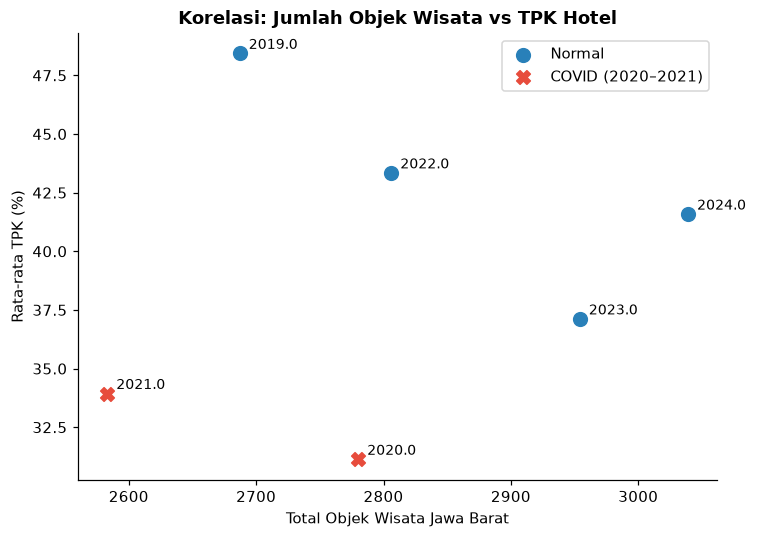

Korelasi Pearson (semua tahun): 0.099
Korelasi Pearson (tanpa COVID): -0.797


In [22]:
# Preview korelasi TPK vs total objek wisata
fig, ax = plt.subplots(figsize=(7, 5))
covid_mask = df_merged['tahun'].isin([2020, 2021])

ax.scatter(df_merged[~covid_mask]['total_objek_jabar'],
           df_merged[~covid_mask]['tpk_rata_rata'],
           color='#2980b9', s=80, zorder=3, label='Normal')
ax.scatter(df_merged[covid_mask]['total_objek_jabar'],
           df_merged[covid_mask]['tpk_rata_rata'],
           color='#e74c3c', s=80, marker='X', zorder=3, label='COVID (2020–2021)')

for _, row in df_merged.iterrows():
    ax.annotate(str(row['tahun']),
                (row['total_objek_jabar'], row['tpk_rata_rata']),
                textcoords='offset points', xytext=(6, 3), fontsize=9)

ax.set_xlabel('Total Objek Wisata Jawa Barat')
ax.set_ylabel('Rata-rata TPK (%)')
ax.set_title('Korelasi: Jumlah Objek Wisata vs TPK Hotel', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

corr = df_merged[['tpk_rata_rata','total_objek_jabar']].corr().iloc[0,1]
print(f"Korelasi Pearson (semua tahun): {corr:.3f}")
corr_no_covid = df_merged[~covid_mask][['tpk_rata_rata','total_objek_jabar']].corr().iloc[0,1]
print(f"Korelasi Pearson (tanpa COVID): {corr_no_covid:.3f}")

---
## 3. Export Data Hasil Preprocessing

In [24]:
import os
os.makedirs('../data/preprocessed', exist_ok=True)

hotel.to_csv('../data/preprocessed/hotel_scrubbed.csv', index=False)
odtw.to_csv('../data/preprocessed/odtw_scrubbed.csv', index=False)
odtw_wide.to_csv('../data/preprocessed/odtw_wide.csv', index=False)
df_merged.to_csv('../data/preprocessed/hotel_odtw_merged.csv', index=False)

print("File tersimpan:")
for fname in ['hotel_scrubbed.csv', 'odtw_scrubbed.csv', 'odtw_wide.csv', 'hotel_odtw_merged.csv']:
    path = f'../data/preprocessed/{fname}'
    size = os.path.getsize(path)
    print(f"  {fname:35s} {size:>8,} bytes")

File tersimpan:
  hotel_scrubbed.csv                    17,578 bytes
  odtw_scrubbed.csv                     53,536 bytes
  odtw_wide.csv                         38,072 bytes
  hotel_odtw_merged.csv                    164 bytes
